In [6]:
!pip install yfinance pandas matplotlib
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

!ls /content/*.csv

In [7]:
tickers = {
    "AAPL": "1y",
    "MSFT": "2y",
    "AMZN": "3y",
    "TSLA": "4y",
    "NVDA": "5y"
}

data = {}

for t, period in tickers.items():
    df = yf.download(t, period=period)
    df = df.dropna()

    data[t] = df

    df.to_csv(f"{t}.csv")

/tmp/ipykernel_25914/4240824053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25914/4240824053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25914/4240824053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25914/4240824053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(t, period=period)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_25914/4240824053.py:12: FutureWarning: YF.download() has changed argument auto_adjust default

In [8]:
import datetime

def completeness(df):
    return 1 - df.isnull().sum().sum() / df.size


def latency(df):
    latest = df.index.max().date()
    today = datetime.date.today()
    return (today - latest).days


def accuracy(df):
    return ((df["Close"] <= df["High"]) & (df["Close"] >= df["Low"])).mean()


def consistency(df):
    return ((df["Open"] > 0) & (df["Close"] > 0) & (df["High"] >= df["Low"])).mean()


def compute_kpis(df):
    return {
        "Completeness": completeness(df),
        "Latency": latency(df),
        "Accuracy": accuracy(df),
        "Consistency": consistency(df)
    }

In [9]:
import pandas as pd

results = []

for t in data:
    kpis = compute_kpis(data[t])
    kpis["Ticker"] = t
    results.append(kpis)

kpi_df = pd.DataFrame(results)
kpi_df

,Completeness,Latency,Accuracy,Consistency,Ticker
0,1.0,0,Ticker AAPL 1.0 dtype: float64,Ticker AAPL 1.0 dtype: float64,AAPL
1,1.0,0,Ticker MSFT 1.0 dtype: float64,Ticker MSFT 1.0 dtype: float64,MSFT
2,1.0,0,Ticker AMZN 1.0 dtype: float64,Ticker AMZN 1.0 dtype: float64,AMZN
3,1.0,0,Ticker TSLA 1.0 dtype: float64,Ticker TSLA 1.0 dtype: float64,TSLA
4,1.0,0,Ticker NVDA 1.0 dtype: float64,Ticker NVDA 1.0 dtype: float64,NVDA


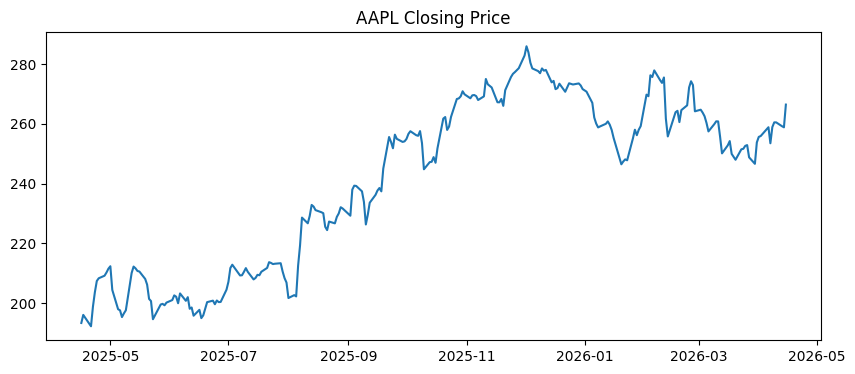

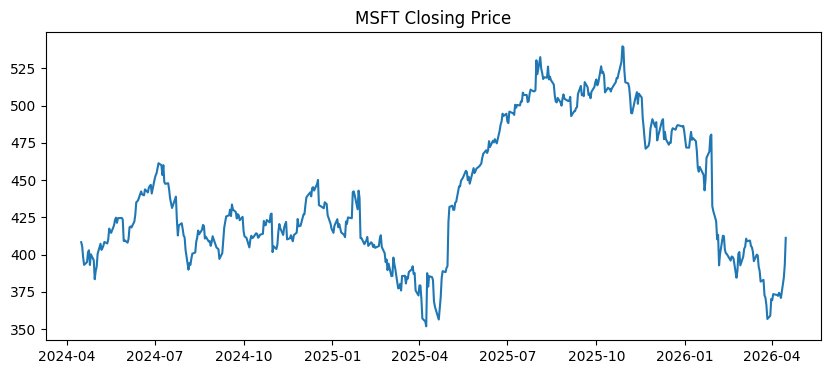

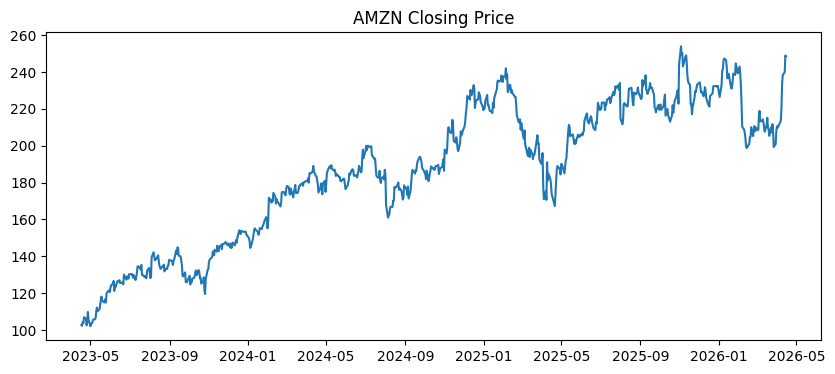

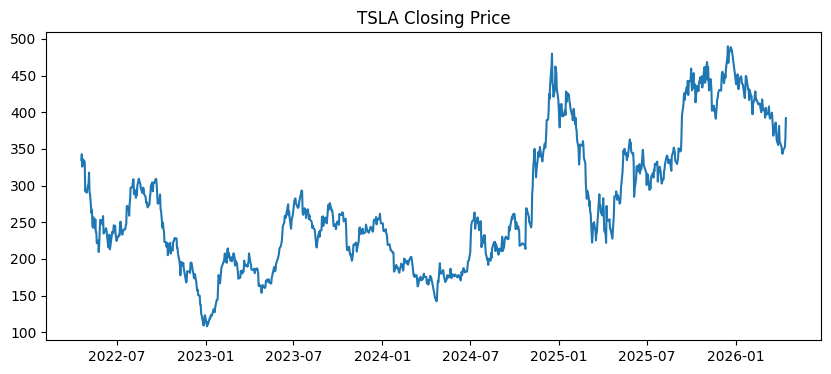

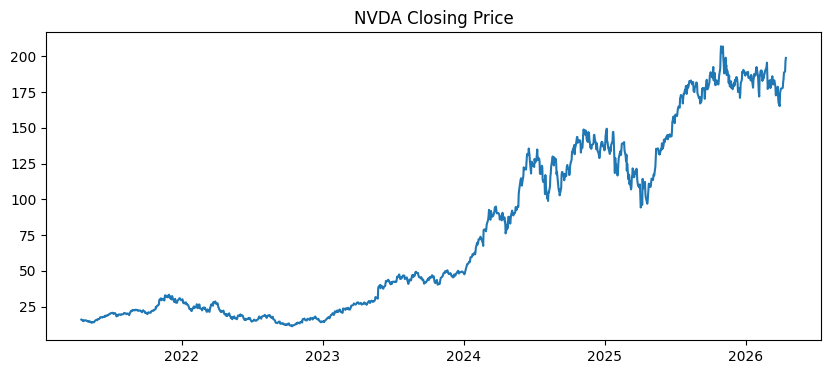

In [10]:
for t, df in data.items():
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df["Close"])
    plt.title(t + " Closing Price")
    plt.show()